# Customer Churn Prediction
## Phase 5 — Baseline Modeling

C:\Users\ckaus\AppData\Local\Temp\ipykernel_9260\2487078265.py:46: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


Numerical: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
X_train: (5634, 19)
X_test: (1409, 19)

Train target:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Test target:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


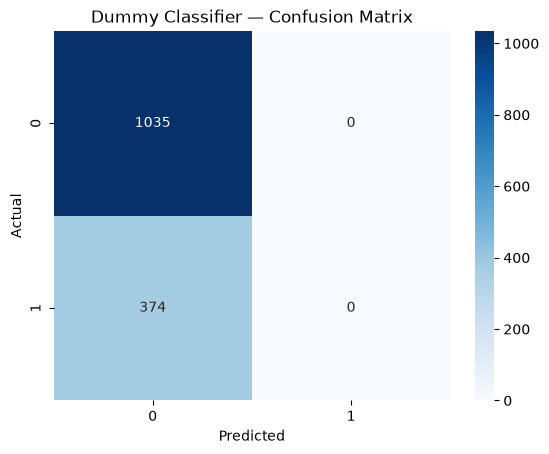

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



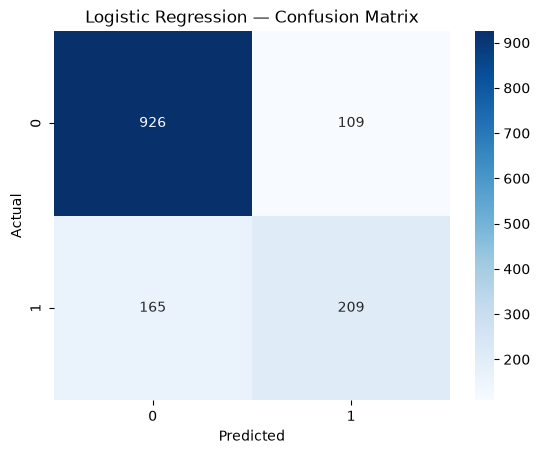

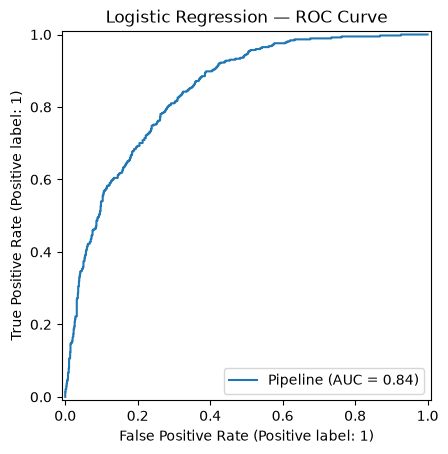

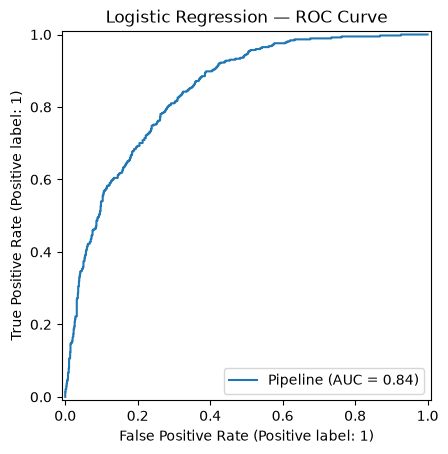

['../models/logistic_regression_baseline.joblib']

In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
df = pd.read_csv(
    "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})
X = df.drop(columns=["Churn", "customerID"])
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical:", numeric_features)
print("Categorical:", categorical_features)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nTrain target:")
print(y_train.value_counts(normalize=True))

print("\nTest target:")
print(y_test.value_counts(normalize=True))

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)
dummy_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DummyClassifier(
                strategy="most_frequent"
            )
        )
    ]
)
dummy_model.fit(
    X_train,
    y_train
)
dummy_pred = dummy_model.predict(X_test)

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    }

    return metrics
dummy_metrics = evaluate_model(
    dummy_model,
    X_test,
    y_test
)

dummy_metrics
cm = confusion_matrix(
    y_test,
    dummy_model.predict(X_test)
)

cm
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Dummy Classifier — Confusion Matrix")

plt.show()

logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)
logistic_model.fit(
    X_train,
    y_train
)
logistic_pred = logistic_model.predict(X_test)

logistic_prob = logistic_model.predict_proba(
    X_test
)[:, 1]

logistic_metrics = evaluate_model(
    logistic_model,
    X_test,
    y_test
)
logistic_metrics

print(
    classification_report(
        y_test,
        logistic_pred,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)

results = pd.DataFrame([
    {
        "Model": "Dummy",
        **dummy_metrics
    },
    {
        "Model": "Logistic Regression",
        **logistic_metrics
    }
])

results
cm = confusion_matrix(
    y_test,
    logistic_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression — Confusion Matrix")

plt.show()
RocCurveDisplay.from_estimator(
    logistic_model,
    X_test,
    y_test
)

plt.title("Logistic Regression — ROC Curve")
plt.show()

RocCurveDisplay.from_estimator(
    logistic_model,
    X_test,
    y_test
)

plt.title("Logistic Regression — ROC Curve")
plt.show()

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    return_train_score=False
)

cv_df = pd.DataFrame(cv_results)

cv_df

cv_summary = {
    "Accuracy": cv_df["test_accuracy"].mean(),
    "Precision": cv_df["test_precision"].mean(),
    "Recall": cv_df["test_recall"].mean(),
    "F1": cv_df["test_f1"].mean(),
    "ROC-AUC": cv_df["test_roc_auc"].mean()
}

cv_summary

cv_std = {
    "Accuracy": cv_df["test_accuracy"].std(),
    "Precision": cv_df["test_precision"].std(),
    "Recall": cv_df["test_recall"].std(),
    "F1": cv_df["test_f1"].std(),
    "ROC-AUC": cv_df["test_roc_auc"].std()
}

cv_std

from pathlib import Path

Path("../models").mkdir(
    parents=True,
    exist_ok=True
)
import joblib

joblib.dump(
    logistic_model,
    "../models/logistic_regression_baseline.joblib"
)